Cell 1 — Runtime sanity + versions

In [78]:
import sys
import platform
import torch

print("=== Runtime Environment Summary ===")
print(f"Python            : {sys.version.split()[0]}")
print(f"Platform          : {platform.platform()}")
print(f"PyTorch           : {torch.__version__}")

cuda_available = torch.cuda.is_available()
print(f"CUDA available    : {cuda_available}")

if cuda_available:
    dev_id = 0
    props = torch.cuda.get_device_properties(dev_id)

    print(f"GPU               : {torch.cuda.get_device_name(dev_id)}")
    print(f"Compute capability: {props.major}.{props.minor}")
    print(f"Total GPU memory  : {props.total_memory / (1024**3):.2f} GB")

    # Optional runtime details (helpful for debugging)
    print(f"CUDA runtime ver  : {torch.version.cuda}")
    print(f"cuDNN ver         : {torch.backends.cudnn.version()}")

    # CUDA smoke test (verifies context + allocation)
    x = torch.randn(1024, device="cuda")
    y = (x * 2).sum()
    print(f"CUDA smoke test   : tensor {x.shape} on {x.device} | sum={float(y.item()):.3f}")
else:
    print("GPU not detected. Training will run on CPU (slower).")
    print("Tip (Colab): Runtime -> Change runtime type -> Hardware accelerator: GPU")


=== Runtime Environment Summary ===
Python            : 3.12.12
Platform          : Linux-6.6.105+-x86_64-with-glibc2.35
PyTorch           : 2.9.0+cpu
CUDA available    : False
GPU not detected. Training will run on CPU (slower).
Tip (Colab): Runtime -> Change runtime type -> Hardware accelerator: GPU


Cell 2 — Imports + Global Config

In [79]:
# ---------------------------
# Standard library
# ---------------------------
import os
import time
import json
import math
import random
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Set, Optional
from pathlib import Path

# ---------------------------
# External deps: networking + XML parsing
# ---------------------------
import requests
import xml.etree.ElementTree as ET

# ---------------------------
# Scientific + ML stack
# ---------------------------
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------------------
# Plotting
# ---------------------------
import matplotlib.pyplot as plt

# ---------------------------
# Reproducibility utilities
# ---------------------------
def set_seed(seed: int = 42, deterministic: bool = False) -> None:
    """
    Set random seeds for reproducibility.
    deterministic=True enforces more deterministic CUDA behavior (may reduce performance).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        # More deterministic behavior for grading/report reproducibility
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            # Some ops may not support full determinism; ignore gracefully.
            pass
    else:
        # Better performance default
        torch.backends.cudnn.benchmark = True

# Set a base seed for the notebook
set_seed(42, deterministic=False)

# Optional: improves GEMM performance on recent GPUs without changing correctness
# (Safe to keep; does nothing harmful on CPU/older GPUs.)
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

# ---------------------------
# Centralized configuration
# ---------------------------
@dataclass
class CFG:
    # KEGG KGML settings
    organism: str = "sce"
    pids: Tuple[str, ...] = ("00010", "00020", "00030", "00620", "01200", "01230")
    kegg_base: str = "https://rest.kegg.jp/get"
    kgml_dir: str = "kgml_cache"
    polite_sleep: float = 0.35  # Be gentle to KEGG servers

    # Graph construction policies
    # If a KGML gene entry lists multiple genes, expand into multiple nodes (recommended)
    expand_multi_gene_entries: bool = True
    # If True, drop genes with missing/empty reaction annotations (only if justified in report)
    drop_zero_reaction_genes: bool = False

    # Node features (simple + interpretable; avoid label leakage)
    use_log_degree: bool = True
    add_constant_feature: bool = True
    normalize_features: bool = True

    # Data splits
    val_ratio: float = 0.2
    split_seed: int = 42

    # Model choice (must implement layers from scratch; PyG/DGL forbidden)
    model_type: str = "gcn"  # "gcn" or "gat"
    hidden_dim: int = 64
    num_layers: int = 2      # for GCNNet; keep >=2
    dropout: float = 0.35

    # Optimizer/training
    lr: float = 1e-2
    weight_decay: float = 5e-4
    epochs: int = 250
    grad_clip: float = 1.0

    # Early stopping
    early_stop: bool = True
    patience: int = 30
    monitor: str = "val_f1"  # "val_loss" or "val_f1"

    # Outputs
    save_dir: str = "outputs"

def validate_cfg(cfg: CFG) -> None:
    """Fail fast on invalid settings to avoid silent errors later."""
    assert cfg.organism, "organism must be non-empty"
    assert len(cfg.pids) > 0, "pids must be non-empty"
    assert 0.0 < cfg.val_ratio < 1.0, "val_ratio must be in (0,1)"
    assert cfg.model_type.lower() in {"gcn", "gat"}, "model_type must be 'gcn' or 'gat'"
    assert cfg.hidden_dim > 0, "hidden_dim must be positive"
    assert cfg.num_layers >= 2, "num_layers must be >= 2"
    assert 0.0 <= cfg.dropout < 1.0, "dropout must be in [0,1)"
    assert cfg.lr > 0.0, "lr must be positive"
    assert cfg.weight_decay >= 0.0, "weight_decay must be >= 0"
    assert cfg.epochs > 0, "epochs must be positive"
    assert cfg.patience >= 1, "patience must be >= 1"
    assert cfg.monitor in {"val_loss", "val_f1"}, "monitor must be 'val_loss' or 'val_f1'"

cfg = CFG()
validate_cfg(cfg)

# Device helper
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure output/cache directories exist (good practice for Colab runs)
Path(cfg.kgml_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.save_dir).mkdir(parents=True, exist_ok=True)

print("=== Config ===")
print(cfg)
print("Device:", device)


=== Config ===
CFG(organism='sce', pids=('00010', '00020', '00030', '00620', '01200', '01230'), kegg_base='https://rest.kegg.jp/get', kgml_dir='kgml_cache', polite_sleep=0.35, expand_multi_gene_entries=True, drop_zero_reaction_genes=False, use_log_degree=True, add_constant_feature=True, normalize_features=True, val_ratio=0.2, split_seed=42, model_type='gcn', hidden_dim=64, num_layers=2, dropout=0.35, lr=0.01, weight_decay=0.0005, epochs=250, grad_clip=1.0, early_stop=True, patience=30, monitor='val_f1', save_dir='outputs')
Device: cpu


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


Cell 3 — KEGG KGML downloader (cache + retries)

In [80]:
from pathlib import Path

def _looks_like_kgml_bytes(content: bytes) -> bool:
    """
    Stronger sanity check for KGML:
      - must look like XML
      - must contain <pathway and at least one <entry
    """
    head = content[:50000]  # small window is enough
    return (b"<pathway" in head) and (b"<entry" in head) and (b"<" in head)

def _is_probably_kgml_file(path: Path) -> bool:
    """Validate cached file quickly without fully parsing XML (fast)."""
    try:
        if (not path.exists()) or path.stat().st_size <= 0:
            return False
        with path.open("rb") as f:
            content = f.read(50000)
        return _looks_like_kgml_bytes(content)
    except Exception:
        return False

def download_kgml(
    pid: str,
    cfg: CFG,
    session: Optional[requests.Session] = None,
    force: bool = False,
    max_retries: int = 6,
    timeout: int = 30
) -> str:
    """
    Download KGML for KEGG pathway pid (organism-specific) and cache locally.

    Args:
        pid: pathway numeric id string e.g. "00010"
        cfg: configuration (organism, base URL, cache dir, politeness delay)
        session: optional requests.Session for connection pooling
        force: if True, re-download even if cached
        max_retries: number of retries on failure
        timeout: request timeout seconds

    Returns:
        Local path to KGML file as a string.
    """
    cache_dir = Path(cfg.kgml_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    out_path = cache_dir / f"{cfg.organism}{pid}.kgml"

    # Serve from cache when possible
    if (not force) and _is_probably_kgml_file(out_path):
        return str(out_path)

    url = f"{cfg.kegg_base}/{cfg.organism}{pid}/kgml"
    sess = session or requests.Session()

    last_err = None
    for attempt in range(1, max_retries + 1):
        try:
            r = sess.get(
                url,
                timeout=timeout,
                headers={"User-Agent": "BioinfoGNNHomework/1.0"}
            )
            r.raise_for_status()

            content = r.content
            if not _looks_like_kgml_bytes(content):
                raise ValueError(f"Response does not look like KGML XML for pid={pid}.")

            # Atomic write: write to temp then replace
            tmp_path = out_path.with_suffix(".kgml.tmp")
            with tmp_path.open("wb") as f:
                f.write(content)
            tmp_path.replace(out_path)

            # Final cache validation
            if not _is_probably_kgml_file(out_path):
                raise ValueError(f"Saved KGML file failed sanity check for pid={pid}.")

            # Polite sleep to avoid hammering KEGG
            time.sleep(cfg.polite_sleep)
            return str(out_path)

        except Exception as e:
            last_err = e
            # Backoff with small jitter (more polite + avoids sync retry storms)
            jitter = random.random() * 0.1
            time.sleep((0.5 * attempt) + jitter)

    raise RuntimeError(f"Failed to download KGML for pid={pid} from {url}. Last error: {last_err}")

# ---- Download all required pathways (cached) ----
with requests.Session() as sess:
    kgml_paths = [download_kgml(pid, cfg, session=sess, force=False) for pid in cfg.pids]

print("Downloaded KGML files:")
for p in kgml_paths:
    print(" -", p)

kgml_paths


Downloaded KGML files:
 - kgml_cache/sce00010.kgml
 - kgml_cache/sce00020.kgml
 - kgml_cache/sce00030.kgml
 - kgml_cache/sce00620.kgml
 - kgml_cache/sce01200.kgml
 - kgml_cache/sce01230.kgml


['kgml_cache/sce00010.kgml',
 'kgml_cache/sce00020.kgml',
 'kgml_cache/sce00030.kgml',
 'kgml_cache/sce00620.kgml',
 'kgml_cache/sce01200.kgml',
 'kgml_cache/sce01230.kgml']

Cell 4 — KGML parsing utilities (genes, reactions, relations)

In [81]:
def _strip_xml_ns(tag: str) -> str:
    """Remove XML namespace if present: {ns}entry -> entry."""
    return tag.split("}", 1)[-1] if "}" in tag else tag

def split_gene_names(name_attr: str) -> List[str]:
    """
    Parse KEGG gene 'name' field (space-separated).
    Example: "sce:YAL001C sce:YBR123W" -> ["sce:YAL001C", "sce:YBR123W"]
    """
    if not name_attr:
        return []
    return [t.strip() for t in name_attr.strip().split() if t.strip()]

def split_reactions(reaction_attr: str) -> Set[str]:
    """
    Parse reaction attribute. Normalize by removing 'rn:' prefix.
    Example: "rn:R00010 R12345" -> {"R00010", "R12345"}
    """
    if not reaction_attr:
        return set()
    toks = [t.strip() for t in reaction_attr.strip().split() if t.strip()]
    return {t.replace("rn:", "") for t in toks}

def _expand_multi_gene_entries(cfg: CFG) -> bool:
    """
    Backward-compatible switch:
      - prefers cfg.expand_multi_gene_entries
      - otherwise uses cfg.treat_group_gene_entry_as_multiple_nodes (older name)
      - defaults to True if neither exists
    """
    if hasattr(cfg, "expand_multi_gene_entries"):
        return bool(getattr(cfg, "expand_multi_gene_entries"))
    if hasattr(cfg, "treat_group_gene_entry_as_multiple_nodes"):
        return bool(getattr(cfg, "treat_group_gene_entry_as_multiple_nodes"))
    return True

def parse_kgml_file(path: str, pid: str, cfg: CFG):
    """
    Parse a KGML (XML) pathway file and extract gene nodes, reactions, and gene-gene relations.

    Returns:
      entryid_to_genes: Dict[str, List[str]]
          KGML internal entry id -> list of KEGG gene ids (expanded if multi-gene entry)
      gene_to_rxnset: Dict[str, Set[str]]
          KEGG gene id -> set(reaction ids) derived from the 'reaction' attribute
      edges_undirected: Set[Tuple[str,str]]
          Undirected gene-gene edges (stored as (u,v) with u < v)
      gene_to_pathways: Dict[str, Set[str]]
          KEGG gene id -> set of pathway ids where it appears
      stats: Dict[str, int]
          Per-pathway parsing stats for reporting/QC
    """
    tree = ET.parse(path)
    root = tree.getroot()

    entryid_to_genes: Dict[str, List[str]] = {}
    gene_to_rxnset: Dict[str, Set[str]] = {}
    gene_to_pathways: Dict[str, Set[str]] = {}

    stats = {
        "pid": pid,
        "gene_entries": 0,
        "multi_gene_entries": 0,
        "genes_total_expanded": 0,
        "genes_with_reaction_attr": 0,
        "genes_without_reaction_attr": 0,
        "relations_total": 0,
        "gene_gene_relations_used": 0,
        "edges_undirected": 0,
    }

    expand_multi = _expand_multi_gene_entries(cfg)

    # ---- 1) Parse <entry> elements (gene nodes) ----
    # Namespace-safe: iterate over all elements and match by stripped tag name.
    for elem in root.iter():
        if _strip_xml_ns(elem.tag) != "entry":
            continue
        if elem.get("type") != "gene":
            continue

        stats["gene_entries"] += 1

        eid = elem.get("id")  # KGML internal numeric id as string
        if eid is None:
            continue

        genes = split_gene_names(elem.get("name", ""))
        if not genes:
            continue

        if len(genes) > 1:
            stats["multi_gene_entries"] += 1

        # Policy: expand multi-gene entries into multiple nodes (recommended),
        # or collapse into a single "group node" if expand_multi=False.
        if (not expand_multi) and (len(genes) > 1):
            genes = ["|".join(genes)]

        entryid_to_genes[eid] = genes
        stats["genes_total_expanded"] += len(genes)

        rxn_attr = elem.get("reaction", "")
        rxns = split_reactions(rxn_attr) if rxn_attr else set()

        for g in genes:
            gene_to_pathways.setdefault(g, set()).add(pid)
            gene_to_rxnset.setdefault(g, set()).update(rxns)

            if rxn_attr:
                stats["genes_with_reaction_attr"] += 1
            else:
                stats["genes_without_reaction_attr"] += 1

    # ---- 2) Parse <relation> elements (gene-gene edges) ----
    edges_undirected: Set[Tuple[str, str]] = set()

    for elem in root.iter():
        if _strip_xml_ns(elem.tag) != "relation":
            continue

        stats["relations_total"] += 1

        e1 = elem.get("entry1")
        e2 = elem.get("entry2")

        # Only consider relations where both endpoints are gene entries
        if (e1 not in entryid_to_genes) or (e2 not in entryid_to_genes):
            continue

        stats["gene_gene_relations_used"] += 1

        genes1 = entryid_to_genes[e1]
        genes2 = entryid_to_genes[e2]

        # Expand group-to-group relation into all gene-gene pairs
        for g1 in genes1:
            for g2 in genes2:
                if g1 == g2:
                    continue
                u, v = (g1, g2) if g1 < g2 else (g2, g1)
                edges_undirected.add((u, v))

    stats["edges_undirected"] = len(edges_undirected)
    return entryid_to_genes, gene_to_rxnset, edges_undirected, gene_to_pathways, stats


Cell 5 — Merge all pathways into one graph

In [82]:
from collections import defaultdict

def build_merged_graph(
    cfg: CFG,
    kgml_paths: List[str],
    remove_isolated_nodes: bool = False,
    add_self_loops_to_graph: bool = False
):
    """
    Merge multiple KGML pathway graphs into a single undirected graph.

    Args:
        cfg: configuration (includes pids and graph policies)
        kgml_paths: list of downloaded KGML file paths aligned with cfg.pids
        remove_isolated_nodes: if True, drop nodes with degree 0 (usually keep False for homework)
        add_self_loops_to_graph: if True, explicitly add (i,i) edges in edge_index
                                (not required; GCN/GAT typically add self-loops internally)

    Returns:
        genes: list of KEGG gene IDs (node names) in index order
        node2idx / idx2node: mappings
        edge_index: torch.LongTensor [2, E] with both directions included
        gene_to_rxnset: gene -> set(reaction IDs)
        gene_to_pathways: gene -> set(pids)
        graph_stats: dict of useful graph statistics for the report
    """
    all_edges: Set[Tuple[str, str]] = set()
    gene_to_rxnset: Dict[str, Set[str]] = defaultdict(set)
    gene_to_pathways: Dict[str, Set[str]] = defaultdict(set)
    parsing_stats = []

    # ---------------------------
    # Parse each KGML and merge
    # ---------------------------
    for pid, path in zip(cfg.pids, kgml_paths):
        parsed = parse_kgml_file(path, pid, cfg)

        # Support both formats: (4-tuple) or (5-tuple with stats)
        if len(parsed) == 5:
            _, rxnset, edges, pathways, st = parsed
            parsing_stats.append(st)
        else:
            _, rxnset, edges, pathways = parsed
            parsing_stats.append({"pid": pid, "note": "parser_stats_not_returned"})

        # Merge reaction sets + pathways
        for g, rs in rxnset.items():
            gene_to_rxnset[g].update(rs)
        for g, ps in pathways.items():
            gene_to_pathways[g].update(ps)

        # Merge edges
        all_edges |= edges

    # ---------------------------
    # Build node set
    # ---------------------------
    genes_set = set(gene_to_rxnset.keys()) | set(gene_to_pathways.keys())
    for u, v in all_edges:
        genes_set.add(u)
        genes_set.add(v)

    # Backward-compatible config flag resolution
    # (older name: drop_genes_with_zero_reactions)
    drop_zero = getattr(cfg, "drop_zero_reaction_genes", None)
    if drop_zero is None:
        drop_zero = getattr(cfg, "drop_genes_with_zero_reactions", False)

    if drop_zero:
        genes_set = {g for g in genes_set if len(gene_to_rxnset.get(g, set())) > 0}
        all_edges = {(u, v) for (u, v) in all_edges if (u in genes_set and v in genes_set)}

    # Deterministic node ordering
    genes = sorted(list(genes_set))
    node2idx = {g: i for i, g in enumerate(genes)}
    idx2node = {i: g for g, i in node2idx.items()}

    # ---------------------------
    # Build directed edge list (both directions)
    # ---------------------------
    # Deterministic edge ordering for reproducibility
    all_edges_sorted = sorted(list(all_edges))

    edge_list = []
    for u, v in all_edges_sorted:
        ui = node2idx.get(u, None)
        vi = node2idx.get(v, None)
        if ui is None or vi is None:
            continue
        edge_list.append((ui, vi))
        edge_list.append((vi, ui))

    # Optional: add self-loops explicitly
    if add_self_loops_to_graph:
        for i in range(len(genes)):
            edge_list.append((i, i))

    if len(edge_list) == 0:
        raise RuntimeError("No edges were constructed. Check KGML parsing / relations filtering.")

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()  # [2, E]

    # ---------------------------
    # Optional: remove isolated nodes
    # ---------------------------
    if remove_isolated_nodes:
        src = edge_index[0]
        deg = torch.zeros(len(genes), dtype=torch.long)
        deg.scatter_add_(0, src, torch.ones_like(src, dtype=torch.long))

        keep = (deg > 0).nonzero(as_tuple=False).view(-1)
        old_to_new = -torch.ones(len(genes), dtype=torch.long)
        old_to_new[keep] = torch.arange(len(keep), dtype=torch.long)

        src_new = old_to_new[edge_index[0]]
        dst_new = old_to_new[edge_index[1]]
        mask = (src_new >= 0) & (dst_new >= 0)

        edge_index = torch.stack([src_new[mask], dst_new[mask]], dim=0)

        genes = [genes[i] for i in keep.tolist()]
        node2idx = {g: i for i, g in enumerate(genes)}
        idx2node = {i: g for g, i in node2idx.items()}

    # ---------------------------
    # Graph statistics (report-friendly)
    # ---------------------------
    N = len(genes)
    E_dir = int(edge_index.size(1))
    E_undir = E_dir // 2  # because we explicitly stored both directions

    # Degree stats (out-degree; since both directions exist, equals undirected degree)
    src = edge_index[0]
    deg = torch.zeros(N, dtype=torch.long)
    deg.scatter_add_(0, src, torch.ones_like(src, dtype=torch.long))

    graph_stats = {
        "num_nodes": int(N),
        "num_edges_directed": int(E_dir),
        "num_edges_undirected": int(E_undir),
        "drop_zero_reaction_genes": bool(drop_zero),
        "remove_isolated_nodes": bool(remove_isolated_nodes),
        "add_self_loops_to_graph": bool(add_self_loops_to_graph),
        "isolated_nodes": int((deg == 0).sum().item()),
        "deg_min": int(deg.min().item()) if N else 0,
        "deg_median": float(np.median(deg.numpy())) if N else 0.0,
        "deg_mean": float(deg.float().mean().item()) if N else 0.0,
        "deg_max": int(deg.max().item()) if N else 0,
        "parsing_stats": parsing_stats,
    }

    return genes, node2idx, idx2node, edge_index, dict(gene_to_rxnset), dict(gene_to_pathways), graph_stats


# ---- Build merged graph ----
genes, node2idx, idx2node, edge_index, gene_to_rxnset, gene_to_pathways, graph_stats = build_merged_graph(
    cfg, kgml_paths, remove_isolated_nodes=False, add_self_loops_to_graph=False
)

print("=== Merged Graph ===")
print("Nodes:", graph_stats["num_nodes"])
print("Directed edges (both directions):", graph_stats["num_edges_directed"])
print("Undirected edges (unique):", graph_stats["num_edges_undirected"])
print("Isolated nodes:", graph_stats["isolated_nodes"])
print("Degree stats (min/median/mean/max):",
      graph_stats["deg_min"], graph_stats["deg_median"], f"{graph_stats['deg_mean']:.2f}", graph_stats["deg_max"])


=== Merged Graph ===
Nodes: 222
Directed edges (both directions): 1180
Undirected edges (unique): 590
Isolated nodes: 98
Degree stats (min/median/mean/max): 0 4.0 5.32 19


Cell 6 — Build labels (binary) + QC summary

=== Label Distribution ===
Nodes  : 222
Label0 : 126  (<= 1 reaction)
Label1 : 96  (> 1 reaction)
Ratios : label0=0.568 | label1=0.432

=== Reaction Count QC (from KGML attributes) ===
#rxn==0: 0
#rxn==1: 126
#rxn> 1: 96
min/median/max: 1 1.0 7


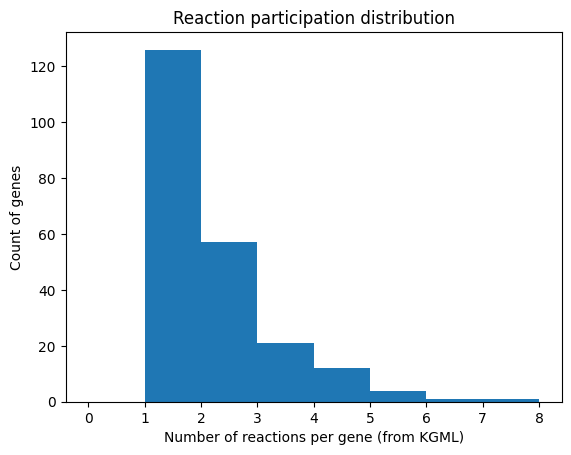

In [83]:
from typing import Any

def build_labels(
    genes: List[str],
    gene_to_rxnset: Dict[str, Set[str]],
    zero_reaction_policy: str = "label0",  # keep default aligned with homework definition
    return_class_indices: bool = True
) -> Tuple[torch.Tensor, np.ndarray, Dict[str, Any]]:
    """
    Create binary node labels from reaction participation encoded in KGML.

    Homework label definition:
      - Label 0: enzyme participates in only one reaction
      - Label 1: enzyme participates in more than one reaction

    Handling genes with 0 reactions in KGML:
      - KGML may omit the 'reaction' attribute for some gene entries.
      - Default: treat 0 as label 0 (<=1 reaction), which is consistent and transparent.
      - If you want to drop these nodes, do it upstream in graph construction and justify in report.

    Args:
        genes: ordered list of KEGG gene IDs (nodes)
        gene_to_rxnset: dict mapping gene -> set of reaction IDs (may be empty)
        zero_reaction_policy: currently supports:
            - "label0": treat 0 reactions as label 0
        return_class_indices: if True, include node indices for each class in qc dict

    Returns:
        y: FloatTensor [N] in {0.0,1.0}
        rxn_counts: np.ndarray [N] reaction count per node
        qc: dict with report-friendly stats and optional class indices
    """
    if zero_reaction_policy != "label0":
        raise ValueError("Only zero_reaction_policy='label0' is supported in this template.")

    N = len(genes)
    rxn_counts = np.zeros(N, dtype=int)

    # Compute reaction counts
    for i, g in enumerate(genes):
        c = len(gene_to_rxnset.get(g, set()))
        if c < 0:
            raise ValueError("Reaction count should never be negative.")
        rxn_counts[i] = c

    # Apply homework label rule: label=1 if more than one reaction else 0
    y = torch.from_numpy((rxn_counts > 1).astype(np.float32))  # [N]

    # Core counts
    n0 = int((y == 0).sum().item())
    n1 = int((y == 1).sum().item())

    # Reaction count QC
    n_eq_0 = int((rxn_counts == 0).sum())
    n_eq_1 = int((rxn_counts == 1).sum())
    n_gt_1 = int((rxn_counts > 1).sum())

    qc: Dict[str, Any] = {
        "num_nodes": int(N),
        "label0": n0,
        "label1": n1,
        "label0_ratio": float(n0 / max(N, 1)),
        "label1_ratio": float(n1 / max(N, 1)),
        "rxn_eq_0": n_eq_0,
        "rxn_eq_1": n_eq_1,
        "rxn_gt_1": n_gt_1,
        "rxn_min": int(rxn_counts.min()) if N else 0,
        "rxn_median": float(np.median(rxn_counts)) if N else 0.0,
        "rxn_max": int(rxn_counts.max()) if N else 0,
    }

    if return_class_indices:
        idx0 = np.where(rxn_counts <= 1)[0]   # label 0 definition
        idx1 = np.where(rxn_counts > 1)[0]    # label 1 definition
        qc["class0_indices"] = idx0.tolist()
        qc["class1_indices"] = idx1.tolist()

    return y, rxn_counts, qc


# ---- Build labels + QC ----
y, rxn_counts, label_qc = build_labels(
    genes, gene_to_rxnset, zero_reaction_policy="label0", return_class_indices=False
)

print("=== Label Distribution ===")
print(f"Nodes  : {label_qc['num_nodes']}")
print(f"Label0 : {label_qc['label0']}  (<= 1 reaction)")
print(f"Label1 : {label_qc['label1']}  (> 1 reaction)")
print(f"Ratios : label0={label_qc['label0_ratio']:.3f} | label1={label_qc['label1_ratio']:.3f}")

print("\n=== Reaction Count QC (from KGML attributes) ===")
print(f"#rxn==0: {label_qc['rxn_eq_0']}")
print(f"#rxn==1: {label_qc['rxn_eq_1']}")
print(f"#rxn> 1: {label_qc['rxn_gt_1']}")
print("min/median/max:", label_qc["rxn_min"], f"{label_qc['rxn_median']:.1f}", label_qc["rxn_max"])

# Optional plot (good for report appendix)
plt.figure()
plt.hist(rxn_counts, bins=range(int(rxn_counts.max()) + 2))
plt.xlabel("Number of reactions per gene (from KGML)")
plt.ylabel("Count of genes")
plt.title("Reaction participation distribution")
plt.show()


Cell 7 — Feature engineering (interpretable, no label leakage, ablation-ready)

In [84]:
from typing import Any

def compute_degree(edge_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
    """
    Compute node degree from edge_index using src counts.
    Since we store both directions for an undirected graph, this equals undirected degree.
    """
    src = edge_index[0]
    deg = torch.zeros(num_nodes, dtype=torch.float32)
    deg.scatter_add_(0, src, torch.ones_like(src, dtype=torch.float32))
    return deg  # [N]

def _zscore_normalize(X: torch.Tensor, eps: float = 1e-6) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Column-wise z-score normalization with safe handling of near-zero variance.
    Returns normalized X plus (mean, std) for reproducibility/reporting.
    """
    mean = X.mean(dim=0, keepdim=True)
    std = X.std(dim=0, keepdim=True)

    # Avoid exploding normalization if a column has ~zero variance
    std_safe = torch.where(std < eps, torch.ones_like(std), std)
    Xn = (X - mean) / std_safe
    return Xn, mean.squeeze(0), std.squeeze(0)

def build_features(
    cfg: CFG,
    genes: List[str],
    edge_index: torch.Tensor,
    gene_to_pathways: Dict[str, Set[str]],
    mode: str = "all",                 # "const", "deg", "pid", "all"
    normalization: str = "zscore"      # "zscore" or "none"
) -> Tuple[torch.Tensor, List[str], Dict[str, Any]]:
    """
    Build simple, interpretable node features (homework focus is on graph learning, not feature engineering).

    Feature candidates:
      1) log(1 + degree)
      2) pathway membership multi-hot (one column per required KEGG pathway)
      3) constant bias feature (appended AFTER normalization)

    Args:
        cfg: configuration
        genes: ordered nodes
        edge_index: [2, E] directed edges (both directions present)
        gene_to_pathways: mapping gene -> set(pathway ids)
        mode: feature subset selection for ablations
        normalization: normalization applied to "core" features (excluding constant)

    Returns:
        X: FloatTensor [N, D]
        feature_names: list of column names (length D) for reporting
        feat_stats: dict with normalization stats and QC info
    """
    N = len(genes)
    pid_list = list(cfg.pids)

    # ---- 1) Degree ----
    deg = compute_degree(edge_index, N).unsqueeze(1)  # [N,1]
    if getattr(cfg, "use_log_degree", True):
        deg = torch.log1p(deg)
    deg_name = "log1p_degree" if getattr(cfg, "use_log_degree", True) else "degree"

    # ---- 2) Pathway membership (multi-hot) ----
    pid_to_col = {pid: i for i, pid in enumerate(pid_list)}
    P = torch.zeros((N, len(pid_list)), dtype=torch.float32)
    for i, g in enumerate(genes):
        for pid in gene_to_pathways.get(g, set()):
            j = pid_to_col.get(pid, None)
            if j is not None:
                P[i, j] = 1.0

    pid_names = [f"pathway_{pid}" for pid in pid_list]

    # ---- Assemble core features (excluding constant) ----
    if mode == "const":
        X_core = torch.zeros((N, 0), dtype=torch.float32)
        core_names: List[str] = []
    elif mode == "deg":
        X_core = deg
        core_names = [deg_name]
    elif mode == "pid":
        X_core = P
        core_names = pid_names
    elif mode == "all":
        X_core = torch.cat([deg, P], dim=1)
        core_names = [deg_name] + pid_names
    else:
        raise ValueError("mode must be one of: 'const', 'deg', 'pid', 'all'")

    feat_stats: Dict[str, Any] = {
        "mode": mode,
        "normalization": normalization,
        "core_dim": int(X_core.shape[1]),
        "constant_appended": bool(getattr(cfg, "add_constant_feature", True)),
    }

    # ---- Normalize core only (so constant does not collapse to zero) ----
    if normalization == "zscore" and X_core.numel() > 0 and getattr(cfg, "normalize_features", True):
        X_core, core_mean, core_std = _zscore_normalize(X_core, eps=1e-6)
        feat_stats["core_mean"] = core_mean.detach().cpu().numpy().tolist()
        feat_stats["core_std"] = core_std.detach().cpu().numpy().tolist()
    elif normalization == "none":
        pass
    else:
        # If cfg.normalize_features=False or core is empty, do nothing
        pass

    # ---- Append constant feature AFTER normalization ----
    feature_names = list(core_names)
    if getattr(cfg, "add_constant_feature", True):
        ones = torch.ones((N, 1), dtype=torch.float32)
        X = torch.cat([X_core, ones], dim=1) if X_core.numel() > 0 else ones
        feature_names.append("bias_const_1")
    else:
        X = X_core

    feat_stats["final_dim"] = int(X.shape[1])
    return X, feature_names, feat_stats


@torch.no_grad()
def feature_label_correlation(X: torch.Tensor, y: torch.Tensor) -> np.ndarray:
    """
    Quick leakage sanity check: compute Pearson corr between each feature column and labels.
    This is NOT used for training, only for debugging/report transparency.
    """
    Xn = X.detach().cpu().numpy()
    yn = y.detach().cpu().numpy()
    corrs = []
    for j in range(Xn.shape[1]):
        xj = Xn[:, j]
        if np.std(xj) < 1e-12:
            corrs.append(0.0)
        else:
            corrs.append(float(np.corrcoef(xj, yn)[0, 1]))
    return np.array(corrs)


# ---- Build default feature matrix ----
X, feature_names, feat_stats = build_features(
    cfg, genes, edge_index, gene_to_pathways, mode="all", normalization="zscore"
)

print("=== Features ===")
print("X shape:", tuple(X.shape), "| y shape:", tuple(y.shape))
print("Feature dims:", X.shape[1])

print("\nFeature columns:")
for j, n in enumerate(feature_names):
    print(f"  col{j:02d}: {n}")

# Report-friendly summary (mean ± std)
print("\nFeature column summary (mean ± std):")
col_mean = X.mean(dim=0).cpu().numpy()
col_std = X.std(dim=0).cpu().numpy()
for j in range(X.shape[1]):
    print(f"  col{j:02d}: mean={col_mean[j]: .3f} std={col_std[j]: .3f}")

# Optional leakage sanity check
corrs = feature_label_correlation(X, y)
print("\nPearson corr(feature, label) (debug):")
for j, n in enumerate(feature_names):
    print(f"  {n:>15s}: {corrs[j]: .3f}")


=== Features ===
X shape: (222, 8) | y shape: (222,)
Feature dims: 8

Feature columns:
  col00: log1p_degree
  col01: pathway_00010
  col02: pathway_00020
  col03: pathway_00030
  col04: pathway_00620
  col05: pathway_01200
  col06: pathway_01230
  col07: bias_const_1

Feature column summary (mean ± std):
  col00: mean=-0.000 std= 1.000
  col01: mean=-0.000 std= 1.000
  col02: mean= 0.000 std= 1.000
  col03: mean=-0.000 std= 1.000
  col04: mean= 0.000 std= 1.000
  col05: mean=-0.000 std= 1.000
  col06: mean=-0.000 std= 1.000
  col07: mean= 1.000 std= 0.000

Pearson corr(feature, label) (debug):
     log1p_degree:  0.056
    pathway_00010:  0.089
    pathway_00020:  0.357
    pathway_00030:  0.024
    pathway_00620: -0.204
    pathway_01200:  0.348
    pathway_01230: -0.166
     bias_const_1:  0.000


Cell 8 — Stratified train/validation split

In [85]:
from typing import Any

def stratified_split(
    y: torch.Tensor,
    val_ratio: float = 0.2,
    seed: int = 42,
    min_per_class_in_val: int = 1,
    min_per_class_in_train: int = 1,
    shuffle: bool = True
) -> Tuple[torch.Tensor, torch.Tensor, Dict[str, Any]]:
    """
    Create a stratified node split for binary labels.

    Args:
        y: FloatTensor [N] with values in {0,1}
        val_ratio: fraction of nodes used for validation
        seed: RNG seed for reproducibility
        min_per_class_in_val: ensures at least this many samples per class in validation (if possible)
        min_per_class_in_train: ensures at least this many samples per class in training (if possible)
        shuffle: shuffle indices within each split

    Returns:
        train_idx: LongTensor indices for training nodes
        val_idx: LongTensor indices for validation nodes
        split_stats: dict with class counts and integrity checks (report-friendly)
    """
    if not (0.0 < val_ratio < 1.0):
        raise ValueError("val_ratio must be between 0 and 1 (exclusive).")

    y_np = y.detach().cpu().numpy().astype(int)
    idx0 = np.where(y_np == 0)[0]
    idx1 = np.where(y_np == 1)[0]

    if len(idx0) == 0 or len(idx1) == 0:
        raise ValueError("Both classes must be present to perform stratified split.")

    rng = np.random.default_rng(seed)
    rng.shuffle(idx0)
    rng.shuffle(idx1)

    # Proposed validation sizes
    n0_val = int(round(len(idx0) * val_ratio))
    n1_val = int(round(len(idx1) * val_ratio))

    # Enforce minimum in validation (when possible)
    n0_val = max(min_per_class_in_val, n0_val) if len(idx0) > (min_per_class_in_val + min_per_class_in_train) else n0_val
    n1_val = max(min_per_class_in_val, n1_val) if len(idx1) > (min_per_class_in_val + min_per_class_in_train) else n1_val

    # Ensure we leave at least min_per_class_in_train samples for training
    n0_val = min(n0_val, max(len(idx0) - min_per_class_in_train, 0))
    n1_val = min(n1_val, max(len(idx1) - min_per_class_in_train, 0))

    # Construct splits
    val_idx = np.concatenate([idx0[:n0_val], idx1[:n1_val]])
    train_idx = np.concatenate([idx0[n0_val:], idx1[n1_val:]])

    if shuffle:
        rng.shuffle(train_idx)
        rng.shuffle(val_idx)

    train_idx_t = torch.tensor(train_idx, dtype=torch.long)
    val_idx_t = torch.tensor(val_idx, dtype=torch.long)

    # ---- Integrity checks ----
    train_set = set(train_idx.tolist())
    val_set = set(val_idx.tolist())

    overlap = len(train_set & val_set)
    covered = len(train_set | val_set)

    split_stats: Dict[str, Any] = {
        "train_size": int(train_idx_t.numel()),
        "val_size": int(val_idx_t.numel()),
        "train_class0": int((y[train_idx_t] == 0).sum().item()),
        "train_class1": int((y[train_idx_t] == 1).sum().item()),
        "val_class0": int((y[val_idx_t] == 0).sum().item()),
        "val_class1": int((y[val_idx_t] == 1).sum().item()),
        "val_ratio": float(val_ratio),
        "seed": int(seed),
        "overlap_nodes": int(overlap),
        "covered_nodes": int(covered),
        "total_nodes": int(y.numel()),
        "shuffle": bool(shuffle),
    }

    # Hard assertions (fail fast if something is wrong)
    assert overlap == 0, "Train/val overlap detected (bug in split logic)."
    assert covered == y.numel(), "Split does not cover all nodes (bug in split logic)."

    return train_idx_t, val_idx_t, split_stats


# ---- Use centralized seed from cfg ----
split_seed = getattr(cfg, "split_seed", 42)
train_idx, val_idx, split_stats = stratified_split(
    y, val_ratio=cfg.val_ratio, seed=split_seed,
    min_per_class_in_val=1, min_per_class_in_train=1, shuffle=True
)

print("=== Split Summary ===")
print(split_stats)


=== Split Summary ===
{'train_size': 178, 'val_size': 44, 'train_class0': 101, 'train_class1': 77, 'val_class0': 25, 'val_class1': 19, 'val_ratio': 0.2, 'seed': 42, 'overlap_nodes': 0, 'covered_nodes': 222, 'total_nodes': 222, 'shuffle': True}


Cell 9 — Metrics (Accuracy/Precision/Recall/F1) + confusion

In [86]:
from typing import Any

@torch.no_grad()
def _binary_confusion_from_probs(
    probs: torch.Tensor,
    y_true: torch.Tensor,
    thr: float
) -> Tuple[int, int, int, int]:
    """Compute TP, TN, FP, FN given probabilities and true labels."""
    preds = (probs >= thr).to(torch.int64)
    y = y_true.to(torch.int64)

    tp = int(((preds == 1) & (y == 1)).sum().item())
    tn = int(((preds == 0) & (y == 0)).sum().item())
    fp = int(((preds == 1) & (y == 0)).sum().item())
    fn = int(((preds == 0) & (y == 1)).sum().item())
    return tp, tn, fp, fn

@torch.no_grad()
def _mcc(tp: int, tn: int, fp: int, fn: int) -> float:
    """Matthews correlation coefficient (robust for imbalance)."""
    num = (tp * tn) - (fp * fn)
    den = math.sqrt(max((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn), 1))
    return float(num / den)

@torch.no_grad()
def _balanced_accuracy(tp: int, tn: int, fp: int, fn: int) -> float:
    """Balanced accuracy = (TPR + TNR) / 2."""
    tpr = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    return float(0.5 * (tpr + tnr))

@torch.no_grad()
def _rank_auc(scores: np.ndarray, labels: np.ndarray) -> float:
    """
    Compute AUROC using a rank-based method (no sklearn).
    Assumes labels are 0/1.
    """
    # If all labels same, AUROC is undefined; return nan
    n_pos = int(labels.sum())
    n_neg = int(len(labels) - n_pos)
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(scores) + 1)

    # Sum of ranks for positive class
    sum_ranks_pos = ranks[labels == 1].sum()
    # Mann–Whitney U statistic
    u = sum_ranks_pos - (n_pos * (n_pos + 1) / 2.0)
    auc = u / (n_pos * n_neg)
    return float(auc)

@torch.no_grad()
def _average_precision(scores: np.ndarray, labels: np.ndarray) -> float:
    """
    Compute AUPRC (Average Precision) without sklearn.
    Standard definition: sum over precision@k for each positive instance (in ranked order).
    """
    n_pos = int(labels.sum())
    if n_pos == 0:
        return float("nan")

    order = np.argsort(-scores)  # descending
    labels_sorted = labels[order]

    tp_cum = np.cumsum(labels_sorted == 1)
    fp_cum = np.cumsum(labels_sorted == 0)

    precision = tp_cum / np.maximum(tp_cum + fp_cum, 1)
    # Average precision = mean of precision at positions where label==1
    ap = precision[labels_sorted == 1].mean()
    return float(ap)

@torch.no_grad()
def compute_metrics_from_logits(
    logits: torch.Tensor,
    y_true: torch.Tensor,
    idx: torch.Tensor,
    thr: float = 0.5,
    extra_curves: bool = True
) -> Dict[str, Any]:
    """
    Compute binary classification metrics on a subset of nodes.

    Required by homework:
      - Accuracy, Precision, Recall, F1
    Also provides:
      - Confusion counts (TP/TN/FP/FN)
      - Balanced accuracy, MCC
      - AUROC, AUPRC (optional; set extra_curves=False to skip)

    Args:
        logits: FloatTensor [N] raw model outputs
        y_true: FloatTensor [N] in {0,1}
        idx: LongTensor indices for the evaluation split
        thr: probability threshold for classification
        extra_curves: compute AUROC/AUPRC (small overhead)

    Returns:
        metrics dict
    """
    # Select split and compute probabilities
    logits_s = logits[idx]
    y_s = y_true[idx].to(torch.float32)
    probs = torch.sigmoid(logits_s)

    tp, tn, fp, fn = _binary_confusion_from_probs(probs, y_s, thr=thr)

    denom = max(tp + tn + fp + fn, 1)
    acc = (tp + tn) / denom

    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = (2 * prec * rec) / max(prec + rec, 1e-12)

    out: Dict[str, Any] = {
        "thr": float(thr),
        "acc": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
        "confusion": [[int(tn), int(fp)], [int(fn), int(tp)]],  # [[TN,FP],[FN,TP]]
        "prob_mean": float(probs.mean().item()),
        "prob_std": float(probs.std().item()),
        "balanced_acc": _balanced_accuracy(tp, tn, fp, fn),
        "mcc": _mcc(tp, tn, fp, fn),
    }

    if extra_curves:
        scores_np = probs.detach().cpu().numpy()
        labels_np = y_s.detach().cpu().numpy().astype(int)
        out["auroc"] = _rank_auc(scores_np, labels_np)
        out["auprc"] = _average_precision(scores_np, labels_np)

    return out

@torch.no_grad()
def evaluate_split(
    model: nn.Module,
    X: torch.Tensor,
    edge_index: torch.Tensor,
    y: torch.Tensor,
    idx: torch.Tensor,
    criterion: Optional[nn.Module] = None,
    thr: float = 0.5,
    logits: Optional[torch.Tensor] = None,
    extra_curves: bool = True
) -> Dict[str, Any]:
    """
    Evaluate model on a split with optional loss computation.

    Args:
        model: trained model
        X: node features [N, D]
        edge_index: [2, E]
        y: labels [N]
        idx: split indices
        criterion: optional loss function (e.g., BCEWithLogitsLoss)
        thr: probability threshold
        logits: optional precomputed logits [N] to avoid re-forwarding
        extra_curves: compute AUROC/AUPRC for additional insight

    Returns:
        metrics dict including loss if criterion is provided
    """
    model.eval()
    if logits is None:
        logits = model(X, edge_index)

    out = compute_metrics_from_logits(logits, y, idx, thr=thr, extra_curves=extra_curves)
    if criterion is not None:
        out["loss"] = float(criterion(logits[idx], y[idx]).item())
    return out


Cell 10 — GCN Layer (from scratch) + Model

In [88]:
from typing import Optional, Tuple

def coalesce_edge_index(edge_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
    """
    Remove duplicate directed edges in edge_index (pure torch).
    For small homework graphs this is fast enough and improves correctness.

    Args:
        edge_index: LongTensor [2, E]
        num_nodes: number of nodes

    Returns:
        edge_index_coalesced: LongTensor [2, E_unique]
    """
    # Map each (src,dst) pair to a unique integer key
    src, dst = edge_index[0], edge_index[1]
    key = src * num_nodes + dst
    key_unique = torch.unique(key, sorted=True)

    src_u = torch.div(key_unique, num_nodes, rounding_mode="floor")
    dst_u = key_unique % num_nodes
    return torch.stack([src_u, dst_u], dim=0)

def add_self_loops(edge_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
    """Append self-loops (i,i) for all nodes."""
    loops = torch.arange(num_nodes, device=edge_index.device, dtype=torch.long)
    loop_index = torch.stack([loops, loops], dim=0)
    return torch.cat([edge_index, loop_index], dim=1)

def prepare_gcn_norm(
    edge_index: torch.Tensor,
    num_nodes: int,
    add_loops: bool = True,
    coalesce: bool = True
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Precompute normalization for GCN on the CURRENT DEVICE.

    Normalization for each directed edge j->i:
        norm_{j->i} = D^{-1/2}_j * D^{-1/2}_i
    where degrees are computed from A_hat (A plus self-loops if add_loops=True).

    Args:
        edge_index: LongTensor [2, E] (directed; undirected graph stored as both directions)
        num_nodes: N
        add_loops: add self-loops (recommended)
        coalesce: remove duplicate edges (recommended)

    Returns:
        edge_index_hat: [2, E_hat]
        norm_hat: [E_hat] float
    """
    if coalesce:
        edge_index = coalesce_edge_index(edge_index, num_nodes)

    if add_loops:
        edge_index_hat = add_self_loops(edge_index, num_nodes)
        if coalesce:
            edge_index_hat = coalesce_edge_index(edge_index_hat, num_nodes)
    else:
        edge_index_hat = edge_index

    row, col = edge_index_hat[0], edge_index_hat[1]  # src, dst

    deg = torch.zeros(num_nodes, device=edge_index_hat.device, dtype=torch.float32)
    deg.scatter_add_(0, row, torch.ones_like(row, dtype=torch.float32))

    deg_inv_sqrt = deg.clamp(min=1.0).pow(-0.5)
    norm_hat = deg_inv_sqrt[row] * deg_inv_sqrt[col]  # [E_hat]

    return edge_index_hat, norm_hat


class GCNLayer(nn.Module):
    """
    GCN layer implemented fully from scratch.

    Given:
      support = XW
      out_i = sum_{j->i} norm_{j->i} * support_j + b

    Notes:
      - Expects edge_index_hat already includes self-loops if you want them.
      - Expects norm_hat aligns with edge_index_hat (same E dimension).
      - No PyG/DGL usage (homework compliant).
    """
    def __init__(self, in_dim: int, out_dim: int, bias: bool = True):
        super().__init__()
        self.W = nn.Parameter(torch.empty(in_dim, out_dim))
        nn.init.xavier_uniform_(self.W)
        self.bias = nn.Parameter(torch.zeros(out_dim)) if bias else None

    def forward(
        self,
        x: torch.Tensor,
        edge_index_hat: torch.Tensor,
        norm_hat: torch.Tensor,
        edge_dropout: float = 0.0
    ) -> torch.Tensor:
        """
        Args:
            x: [N, in_dim]
            edge_index_hat: [2, E_hat] (possibly coalesced, with self-loops)
            norm_hat: [E_hat]
            edge_dropout: probability to drop edges during training (regularization)

        Returns:
            out: [N, out_dim]
        """
        N = x.size(0)
        src, dst = edge_index_hat[0], edge_index_hat[1]

        # Optional edge dropout (message dropout) — only during training
        if self.training and edge_dropout > 0.0:
            keep = torch.rand(src.size(0), device=x.device) >= edge_dropout
            src = src[keep]
            dst = dst[keep]
            norm = norm_hat[keep]
        else:
            norm = norm_hat

        support = x @ self.W  # [N, out_dim]

        out = torch.zeros((N, support.size(1)), device=x.device, dtype=support.dtype)
        msg = support[src] * norm.unsqueeze(1)  # [E, out_dim]
        out.scatter_add_(0, dst.unsqueeze(1).expand_as(msg), msg)

        if self.bias is not None:
            out = out + self.bias
        return out


class GCNNet(nn.Module):
    """
    Multi-layer GCN for binary node classification (logit per node).

    Design choices (still homework-compliant):
      - Residual connections + LayerNorm for stability
      - Dropout between layers
      - Optional edge dropout inside GCNLayer
    """
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        num_layers: int = 2,
        dropout: float = 0.35,
        edge_dropout: float = 0.0,
        use_residual: bool = True,
        use_layernorm: bool = True
    ):
        super().__init__()
        assert num_layers >= 2, "Use >=2 layers: hidden + output."

        self.dropout = dropout
        self.edge_dropout = edge_dropout
        self.use_residual = use_residual

        dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [1]
        self.layers = nn.ModuleList([GCNLayer(d_in, d_out) for d_in, d_out in zip(dims[:-1], dims[1:])])

        self.lns = nn.ModuleList([
            nn.LayerNorm(hidden_dim) if use_layernorm else nn.Identity()
            for _ in range(num_layers - 1)
        ])

        # Residual projection for first hidden layer if needed
        self.res_proj = nn.Linear(in_dim, hidden_dim) if (use_residual and in_dim != hidden_dim) else None

    def forward(
        self,
        x: torch.Tensor,
        edge_index_hat: torch.Tensor,
        norm_hat: torch.Tensor
    ) -> torch.Tensor:
        """
        Args:
            x: [N, in_dim]
            edge_index_hat: [2, E_hat] (precomputed, includes loops)
            norm_hat: [E_hat] (precomputed)

        Returns:
            logits: [N]
        """
        h = x

        # Hidden blocks
        for li in range(len(self.layers) - 1):
            h_next = self.layers[li](h, edge_index_hat, norm_hat, edge_dropout=self.edge_dropout)

            # Residuals
            if self.use_residual:
                if li == 0:
                    res = h if self.res_proj is None else self.res_proj(h)
                    h_next = h_next + res
                else:
                    h_next = h_next + h

            h_next = self.lns[li](h_next)
            h_next = F.relu(h_next)
            h_next = F.dropout(h_next, p=self.dropout, training=self.training)
            h = h_next

        # Output (logits)
        out = self.layers[-1](h, edge_index_hat, norm_hat, edge_dropout=0.0)  # no edge dropout on final layer
        return out.squeeze(1)


# ---- Recommended usage pattern (outside the class): precompute once on device ----
edge_index_d = edge_index.to(device)
edge_index_hat_d, norm_hat_d = prepare_gcn_norm(edge_index_d, num_nodes=X.size(0), add_loops=True, coalesce=True)
model = GCNNet(in_dim=X.size(1), hidden_dim=cfg.hidden_dim, num_layers=getattr(cfg,"num_layers",2),
               dropout=cfg.dropout, edge_dropout=0.1).to(device)
logits = model(X_d, edge_index_hat_d, norm_hat_d)


Cell 11 — GAT Layer from scratch

In [89]:
from typing import Optional, Tuple, Union

def add_self_loops(edge_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
    """Append self-loops (i,i) for all nodes."""
    loops = torch.arange(num_nodes, device=edge_index.device, dtype=torch.long)
    loop_index = torch.stack([loops, loops], dim=0)
    return torch.cat([edge_index, loop_index], dim=1)

def coalesce_edge_index(edge_index: torch.Tensor, num_nodes: int) -> torch.Tensor:
    """Remove duplicate directed edges (pure torch)."""
    src, dst = edge_index[0], edge_index[1]
    key = src * num_nodes + dst
    key_u = torch.unique(key, sorted=True)
    src_u = torch.div(key_u, num_nodes, rounding_mode="floor")
    dst_u = key_u % num_nodes
    return torch.stack([src_u, dst_u], dim=0)

def segment_softmax_2d(scores: torch.Tensor, index: torch.Tensor, num_nodes: int, eps: float = 1e-12) -> torch.Tensor:
    """
    Segment softmax for 2D scores: softmax over segments defined by index (dst nodes).
    scores: [E, H]
    index : [E] (dst for each edge)
    Returns: [E, H] where for each node v and head h:
        alpha_{e,h} = exp(scores_{e,h}) / sum_{e': dst(e')=dst(e)} exp(scores_{e',h})
    """
    device = scores.device
    E, H = scores.shape

    # ---- max per (node, head) for stability ----
    max_per = torch.full((num_nodes, H), -1e30, device=device, dtype=scores.dtype)
    # scatter_reduce_ supports reducing along dim=0 with index [E]; it will reduce rows
    if hasattr(max_per, "scatter_reduce_"):
        max_per.scatter_reduce_(0, index.view(E, 1).expand(E, H), scores, reduce="amax", include_self=True)
    else:
        # Fallback: loop over nodes (still fine for homework-sized graphs)
        for n in torch.unique(index):
            n = int(n.item())
            max_per[n] = torch.maximum(max_per[n], scores[index == n].max(dim=0).values)

    stabilized = scores - max_per[index]              # [E,H]
    exp = torch.exp(stabilized)                       # [E,H]

    sum_per = torch.zeros((num_nodes, H), device=device, dtype=scores.dtype)
    sum_per.scatter_add_(0, index.view(E, 1).expand(E, H), exp)

    return exp / (sum_per[index] + eps)


class GATLayer(nn.Module):
    """
    Graph Attention Layer implemented from scratch.

    Formulation:
      h = XW
      e_{i->j,h} = LeakyReLU( <a_src[h], h_i[h]> + <a_dst[h], h_j[h]> )
      alpha_{i->j,h} = softmax over incoming edges into j (dst) for each head h
      out_j[h] = sum_{i->j} alpha_{i->j,h} * h_i[h]
    """
    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        heads: int = 4,
        concat: bool = True,
        feat_dropout: float = 0.0,
        attn_dropout: float = 0.2,
        add_self_loops_flag: bool = True,
        coalesce: bool = True,
        bias: bool = True
    ):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.heads = heads
        self.concat = concat
        self.feat_dropout = feat_dropout
        self.attn_dropout = attn_dropout
        self.add_self_loops_flag = add_self_loops_flag
        self.coalesce = coalesce

        # Projection: in_dim -> heads*out_dim
        self.W = nn.Parameter(torch.empty(in_dim, heads * out_dim))
        nn.init.xavier_uniform_(self.W)

        # Additive attention vectors
        self.a_src = nn.Parameter(torch.empty(heads, out_dim))
        self.a_dst = nn.Parameter(torch.empty(heads, out_dim))
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)

        self.leakyrelu = nn.LeakyReLU(0.2)
        self.bias = nn.Parameter(torch.zeros(heads * out_dim if concat else out_dim)) if bias else None

    def forward(
        self,
        x: torch.Tensor,
        edge_index: torch.Tensor,
        return_attention: bool = False
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        device = x.device
        N = x.size(0)

        # Feature dropout
        if self.feat_dropout > 0:
            x = F.dropout(x, p=self.feat_dropout, training=self.training)

        # Edge preprocessing (loop + coalesce)
        ei = edge_index
        if self.add_self_loops_flag:
            ei = add_self_loops(ei, N)
        if self.coalesce:
            ei = coalesce_edge_index(ei, N)

        src, dst = ei[0], ei[1]
        E = ei.size(1)

        # Project: [N, H*D] -> [N, H, D]
        h = (x @ self.W).view(N, self.heads, self.out_dim)

        h_src = h[src]  # [E,H,D]
        h_dst = h[dst]  # [E,H,D]

        # Attention logits: [E,H]
        e = (h_src * self.a_src.unsqueeze(0)).sum(-1) + (h_dst * self.a_dst.unsqueeze(0)).sum(-1)
        e = self.leakyrelu(e)

        # Segment softmax over incoming edges to dst (vectorized over heads)
        alpha = segment_softmax_2d(e, dst, N)  # [E,H]

        # Attention dropout
        if self.attn_dropout > 0:
            alpha = F.dropout(alpha, p=self.attn_dropout, training=self.training)

        # Message passing: out[dst] += alpha * h_src
        out = torch.zeros((N, self.heads, self.out_dim), device=device, dtype=h.dtype)
        msg = h_src * alpha.unsqueeze(-1)  # [E,H,D]
        out.scatter_add_(0, dst.view(E, 1, 1).expand_as(msg), msg)

        if self.concat:
            out_final = out.reshape(N, self.heads * self.out_dim)  # [N,H*D]
        else:
            out_final = out.mean(dim=1)  # [N,D]

        if self.bias is not None:
            out_final = out_final + self.bias

        if return_attention:
            return out_final, alpha
        return out_final


class GATNet(nn.Module):
    """
    2-layer GAT network for binary node classification (logits per node).
    Adds (optional) residual + LayerNorm for stability (still from scratch).
    """
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        dropout: float,
        heads: int = 4,
        attn_dropout: float = 0.2,
        feat_dropout: float = 0.0,
        use_residual: bool = True,
        use_layernorm: bool = True
    ):
        super().__init__()
        self.dropout = dropout
        self.use_residual = use_residual

        self.gat1 = GATLayer(
            in_dim=in_dim,
            out_dim=hidden_dim,
            heads=heads,
            concat=True,
            feat_dropout=feat_dropout,
            attn_dropout=attn_dropout,
            add_self_loops_flag=True,
            coalesce=True,
            bias=True
        )

        h1_dim = hidden_dim * heads
        self.ln1 = nn.LayerNorm(h1_dim) if use_layernorm else nn.Identity()
        self.res1 = nn.Linear(in_dim, h1_dim) if (use_residual and in_dim != h1_dim) else None

        self.gat2 = GATLayer(
            in_dim=h1_dim,
            out_dim=1,
            heads=1,
            concat=False,                 # [N,1] -> [N,1]
            feat_dropout=0.0,
            attn_dropout=attn_dropout,
            add_self_loops_flag=True,
            coalesce=True,
            bias=True
        )

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        h = self.gat1(x, edge_index)       # [N, hidden_dim*heads]

        # Residual + norm (stability)
        if self.use_residual:
            res = x if self.res1 is None else self.res1(x)
            h = h + res

        h = self.ln1(h)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        out = self.gat2(h, edge_index)     # [N,1] since concat=False
        return out.squeeze(-1)             # [N]


Cell 12 — Build model + loss (class imbalance-aware)

In [90]:
# ---------------------------
# Device + tensors
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure correct dtypes:
# - Features float32
# - Labels float32 for BCE
# - Edge index long
X_d = X.to(device=device, dtype=torch.float32)
y_d = y.to(device=device, dtype=torch.float32)
edge_index_d = edge_index.to(device=device, dtype=torch.long)
train_idx_d = train_idx.to(device=device, dtype=torch.long)
val_idx_d = val_idx.to(device=device, dtype=torch.long)

# Basic sanity checks (helpful for debugging/grading)
assert X_d.dim() == 2, "X must be [N, D]"
assert y_d.dim() == 1 and y_d.numel() == X_d.size(0), "y must be [N]"
assert edge_index_d.dim() == 2 and edge_index_d.size(0) == 2, "edge_index must be [2, E]"
assert train_idx_d.dim() == 1 and val_idx_d.dim() == 1, "indices must be [K]"

N = X_d.size(0)
D = X_d.size(1)
E = edge_index_d.size(1)

# ---------------------------
# Class imbalance handling (pos_weight for BCEWithLogitsLoss)
# ---------------------------
pos = int((y_d[train_idx_d] == 1).sum().item())
neg = int((y_d[train_idx_d] == 0).sum().item())

# pos_weight = (#neg / #pos) is the standard weighting for BCEWithLogitsLoss
pos_weight = torch.tensor([neg / max(pos, 1)], device=device, dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ---------------------------
# Precompute GCN normalization (ONLY when model_type == "gcn")
# Uses the improved Cell 10 prepare_gcn_norm (add_loops + coalesce) on-device.
# ---------------------------
edge_index_hat_d, norm_hat_d = None, None
if cfg.model_type.lower().strip() == "gcn":
    edge_index_hat_d, norm_hat_d = prepare_gcn_norm(
        edge_index=edge_index_d,
        num_nodes=N,
        add_loops=True,     # add self-loops for A_hat
        coalesce=True       # remove duplicate edges (recommended)
    )
    # Shapes:
    # edge_index_hat_d: [2, E_hat]
    # norm_hat_d: [E_hat]
    assert edge_index_hat_d.size(1) == norm_hat_d.numel(), "GCN norm must align with edges"

# ---------------------------
# Model factory (from-scratch GCN/GAT)
# IMPORTANT: Make sure this matches the upgraded APIs in Cell 10 and Cell 11.
# ---------------------------
def build_model(cfg: CFG, in_dim: int) -> nn.Module:
    """
    Build a model according to cfg.model_type.

    Constraint (homework): GNN layers must be implemented from scratch.
    We only use our GCNLayer/GATLayer, not PyG/DGL.
    """
    mt = cfg.model_type.lower().strip()

    if mt == "gcn":
        num_layers = int(getattr(cfg, "num_layers", 2))
        edge_dropout = float(getattr(cfg, "edge_dropout", 0.0))  # optional regularizer
        return GCNNet(
            in_dim=in_dim,
            hidden_dim=int(cfg.hidden_dim),
            num_layers=num_layers,
            dropout=float(cfg.dropout),
            edge_dropout=edge_dropout,
            use_residual=True,
            use_layernorm=True
        )

    if mt == "gat":
        heads = int(getattr(cfg, "heads", 4))
        attn_dropout = float(getattr(cfg, "attn_dropout", 0.2))
        feat_dropout = float(getattr(cfg, "feat_dropout", 0.0))
        return GATNet(
            in_dim=in_dim,
            hidden_dim=int(cfg.hidden_dim),
            dropout=float(cfg.dropout),
            heads=heads,
            attn_dropout=attn_dropout,
            feat_dropout=feat_dropout,
            use_residual=True,
            use_layernorm=True
        )

    raise ValueError("cfg.model_type must be 'gcn' or 'gat'")

model = build_model(cfg, in_dim=D).to(device)

# ---------------------------
# Optimizer
# ---------------------------
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=float(cfg.lr),
    weight_decay=float(cfg.weight_decay)
)

# ---------------------------
# Mixed Precision (AMP) — modern torch.amp API to avoid FutureWarning
# ---------------------------
use_amp = bool(torch.cuda.is_available())
scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

# ---------------------------
# Print setup summary (report-friendly)
# ---------------------------
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=== Training Setup ===")
print(f"Device        : {device}")
print(f"Graph         : N={N}, D={D}, E(directed)={E}")
print(f"Split sizes   : train={train_idx_d.numel()}, val={val_idx_d.numel()}")
print(f"Model         : {cfg.model_type.upper()}")
print(f"Parameters    : {num_params}")
print(f"Train pos/neg : {pos} / {neg}  | pos_weight={pos_weight.item():.4f}")
print(f"LR            : {cfg.lr} | weight_decay={cfg.weight_decay} | dropout={cfg.dropout}")
print(f"AMP enabled   : {use_amp}")

if cfg.model_type.lower().strip() == "gcn":
    print("GCN norm prepared:",
          f"edge_index_hat={tuple(edge_index_hat_d.shape)}",
          f"norm_hat={tuple(norm_hat_d.shape)}")


=== Training Setup ===
Device        : cpu
Graph         : N=222, D=8, E(directed)=1180
Split sizes   : train=178, val=44
Model         : GCN
Parameters    : 1345
Train pos/neg : 77 / 101  | pos_weight=1.3117
LR            : 0.01 | weight_decay=0.0005 | dropout=0.35
AMP enabled   : False
GCN norm prepared: edge_index_hat=(2, 1402) norm_hat=(1402,)


Cell 13 — Training loop (history, early stopping, gradient clipping)

In [93]:
from copy import deepcopy
from typing import Optional, Dict, Tuple

def forward_logits(
    model: nn.Module,
    X: torch.Tensor,
    edge_index: torch.Tensor,
    cfg: CFG,
    edge_index_hat: Optional[torch.Tensor] = None,
    norm_hat: Optional[torch.Tensor] = None
) -> torch.Tensor:
    """Model-type aware forward pass (GCN uses precomputed norm if provided)."""
    mt = cfg.model_type.lower().strip()
    if mt == "gcn":
        if edge_index_hat is not None and norm_hat is not None:
            # If your GCNNet expects keyword, switch to: model(X, edge_index_hat, norm_hat=norm_hat)
            return model(X, edge_index_hat, norm_hat)
        return model(X, edge_index)
    elif mt == "gat":
        return model(X, edge_index)
    else:
        raise ValueError("cfg.model_type must be 'gcn' or 'gat'")

@torch.no_grad()
def evaluate_epoch(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    edge_index: torch.Tensor,
    train_idx: torch.Tensor,
    val_idx: torch.Tensor,
    criterion: nn.Module,
    cfg: CFG,
    edge_index_hat: Optional[torch.Tensor] = None,
    norm_hat: Optional[torch.Tensor] = None,
    thr: float = 0.5
) -> Tuple[Dict[str, float], Dict[str, float]]:
    """Compute loss + metrics on train and validation splits."""
    model.eval()
    logits = forward_logits(model, X, edge_index, cfg, edge_index_hat=edge_index_hat, norm_hat=norm_hat)

    tr_loss = float(criterion(logits[train_idx], y[train_idx]).item())
    va_loss = float(criterion(logits[val_idx],   y[val_idx]).item())

    tr = compute_metrics_from_logits(logits, y, train_idx, thr=thr)
    va = compute_metrics_from_logits(logits, y, val_idx,   thr=thr)

    tr["loss"] = tr_loss
    va["loss"] = va_loss
    return tr, va

def train_loop(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    edge_index: torch.Tensor,
    train_idx: torch.Tensor,
    val_idx: torch.Tensor,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    cfg: CFG,
    edge_index_hat: Optional[torch.Tensor] = None,
    norm_hat: Optional[torch.Tensor] = None,
    scaler: Optional[object] = None,   # torch.amp.GradScaler or None
    use_amp: bool = False,
    print_every: int = 10,
    thr_eval: float = 0.5
):
    """
    Train a GNN for binary node classification with early stopping.
    Returns:
      history, best_epoch, best_val, best_state
    """
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [],  "val_acc": [],
        "train_precision": [], "val_precision": [],
        "train_recall": [], "val_recall": [],
        "train_f1": [], "val_f1": [],
        "lr": []
    }

    # ---- Optional scheduler (without 'verbose' for compatibility) ----
    use_scheduler = bool(getattr(cfg, "use_scheduler", True))
    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode=("min" if cfg.monitor == "val_loss" else "max"),
            factor=float(getattr(cfg, "lr_factor", 0.5)),
            patience=int(getattr(cfg, "lr_patience", 10)),
            threshold=float(getattr(cfg, "lr_threshold", 1e-4)),
            min_lr=float(getattr(cfg, "min_lr", 1e-5)),
        )

    # ---- AMP (modern API, safe on CPU) ----
    if scaler is None:
        scaler = torch.amp.GradScaler("cuda", enabled=bool(use_amp)) if use_amp else None

    best_state = None
    best_score = None
    best_epoch = 0
    best_val = None
    bad_epochs = 0

    for epoch in range(1, int(cfg.epochs) + 1):
        # -----------------------
        # Train step
        # -----------------------
        model.train()
        optimizer.zero_grad(set_to_none=True)

        # autocast: only relevant on CUDA
        autocast_ctx = torch.amp.autocast("cuda", enabled=bool(use_amp))
        with autocast_ctx:
            logits = forward_logits(model, X, edge_index, cfg, edge_index_hat=edge_index_hat, norm_hat=norm_hat)
            loss = criterion(logits[train_idx], y[train_idx])

        if use_amp and scaler is not None:
            scaler.scale(loss).backward()
            if cfg.grad_clip and cfg.grad_clip > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), float(cfg.grad_clip))
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if cfg.grad_clip and cfg.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), float(cfg.grad_clip))
            optimizer.step()

        # -----------------------
        # Eval step
        # -----------------------
        tr, va = evaluate_epoch(
            model=model,
            X=X, y=y,
            edge_index=edge_index,
            train_idx=train_idx, val_idx=val_idx,
            criterion=criterion,
            cfg=cfg,
            edge_index_hat=edge_index_hat,
            norm_hat=norm_hat,
            thr=thr_eval
        )

        # -----------------------
        # History
        # -----------------------
        history["train_loss"].append(tr["loss"])
        history["val_loss"].append(va["loss"])
        history["train_acc"].append(tr["acc"])
        history["val_acc"].append(va["acc"])
        history["train_precision"].append(tr["precision"])
        history["val_precision"].append(va["precision"])
        history["train_recall"].append(tr["recall"])
        history["val_recall"].append(va["recall"])
        history["train_f1"].append(tr["f1"])
        history["val_f1"].append(va["f1"])
        history["lr"].append(float(optimizer.param_groups[0]["lr"]))

        # -----------------------
        # Scheduler step
        # -----------------------
        if scheduler is not None:
            if cfg.monitor == "val_loss":
                scheduler.step(va["loss"])
            else:
                scheduler.step(va["f1"])

        # -----------------------
        # Early stopping monitor
        # -----------------------
        if cfg.monitor == "val_loss":
            score = -va["loss"]
        else:
            score = va["f1"]

        improved = (best_score is None) or (score > best_score + 1e-6)
        if improved:
            best_score = score
            best_epoch = epoch
            best_val = deepcopy(va)
            best_state = deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
            bad_epochs = 0
        else:
            bad_epochs += 1

        # Print progress
        if epoch == 1 or (epoch % int(print_every) == 0):
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={tr['loss']:.4f} val_loss={va['loss']:.4f} | "
                f"val_acc={va['acc']:.3f} val_f1={va['f1']:.3f} "
                f"(P={va['precision']:.3f}, R={va['recall']:.3f}) | "
                f"lr={optimizer.param_groups[0]['lr']:.2e} | "
                f"best_epoch={best_epoch:03d}"
            )

        if bool(cfg.early_stop) and bad_epochs >= int(cfg.patience):
            print(f"Early stopping at epoch {epoch} (no improvement for {cfg.patience} epochs).")
            break

    # Restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_epoch, best_val, best_state


# ---- Run training ----
history, best_epoch, best_val, _ = train_loop(
    model=model,
    X=X_d,
    y=y_d,
    edge_index=edge_index_d,
    train_idx=train_idx_d,
    val_idx=val_idx_d,
    criterion=criterion,
    optimizer=optimizer,
    cfg=cfg,
    edge_index_hat=edge_index_hat_d,   # used for GCN
    norm_hat=norm_hat_d,               # used for GCN
    scaler=scaler,
    use_amp=use_amp,
    print_every=10,
    thr_eval=0.5
)

print("\n=== Best checkpoint ===")
print("best_epoch:", best_epoch)
print("best_val_metrics:", best_val)


Epoch 001 | train_loss=0.7621 val_loss=0.7297 | val_acc=0.682 val_f1=0.632 (P=0.632, R=0.632) | lr=1.00e-02 | best_epoch=001
Epoch 010 | train_loss=0.6565 val_loss=0.6233 | val_acc=0.682 val_f1=0.611 (P=0.647, R=0.579) | lr=1.00e-02 | best_epoch=003
Epoch 020 | train_loss=0.6429 val_loss=0.6273 | val_acc=0.705 val_f1=0.629 (P=0.688, R=0.579) | lr=1.00e-02 | best_epoch=013
Epoch 030 | train_loss=0.6335 val_loss=0.6276 | val_acc=0.705 val_f1=0.649 (P=0.667, R=0.632) | lr=5.00e-03 | best_epoch=026
Epoch 040 | train_loss=0.6297 val_loss=0.6263 | val_acc=0.795 val_f1=0.757 (P=0.778, R=0.737) | lr=5.00e-03 | best_epoch=037
Epoch 050 | train_loss=0.6244 val_loss=0.6229 | val_acc=0.773 val_f1=0.722 (P=0.765, R=0.684) | lr=2.50e-03 | best_epoch=037
Epoch 060 | train_loss=0.6225 val_loss=0.6253 | val_acc=0.773 val_f1=0.722 (P=0.765, R=0.684) | lr=1.25e-03 | best_epoch=037
Early stopping at epoch 67 (no improvement for 30 epochs).

=== Best checkpoint ===
best_epoch: 37
best_val_metrics: {'thr': 

Cell 14 — Final evaluation

In [94]:
from typing import Optional, Dict, Tuple

@torch.no_grad()
def get_logits_final(
    model: nn.Module,
    X: torch.Tensor,
    edge_index: torch.Tensor,
    cfg: CFG,
    edge_index_hat: Optional[torch.Tensor] = None,
    norm_hat: Optional[torch.Tensor] = None
) -> torch.Tensor:
    """Model-type aware forward pass for evaluation."""
    model.eval()
    mt = cfg.model_type.lower().strip()

    if mt == "gcn" and (edge_index_hat is not None) and (norm_hat is not None):
        # If your GCNNet.forward signature is (x, edge_index, norm_hat=None)
        return model(X, edge_index_hat, norm_hat=norm_hat)

    return model(X, edge_index)


@torch.no_grad()
def metrics_with_loss(
    logits: torch.Tensor,
    y_true: torch.Tensor,
    idx: torch.Tensor,
    criterion: Optional[nn.Module] = None,
    thr: float = 0.5
) -> Dict[str, float]:
    """Compute metrics + optionally add BCE loss for the selected split."""
    m = compute_metrics_from_logits(logits, y_true, idx, thr=thr)
    if criterion is not None:
        m["loss"] = float(criterion(logits[idx], y_true[idx]).item())
    return m


@torch.no_grad()
def print_confusion(m: Dict[str, float], title: str):
    """Pretty-print confusion matrix counts."""
    print(title)
    print(f"  TP={m['tp']}  FP={m['fp']}")
    print(f"  FN={m['fn']}  TN={m['tn']}")


@torch.no_grad()
def tune_threshold_on_val(
    logits: torch.Tensor,
    y_true: torch.Tensor,
    val_idx: torch.Tensor,
    criterion: Optional[nn.Module] = None,
    steps: int = 81
) -> Tuple[float, Dict[str, float]]:
    """
    Tune threshold on the validation set to maximize F1.
    Important: If you report tuned-threshold results, mention it explicitly in the report.
    """
    thrs = torch.linspace(0.0, 1.0, steps=steps, device=logits.device)

    best_thr = 0.5
    best_m = None
    best_f1 = -1.0

    for thr in thrs:
        m = metrics_with_loss(logits, y_true, val_idx, criterion=criterion, thr=float(thr.item()))
        if m["f1"] > best_f1:
            best_f1 = m["f1"]
            best_thr = float(thr.item())
            best_m = m

    return best_thr, best_m


# ---------------------------
# 1) Compute logits (GCN/GAT aware)
# ---------------------------
logits = get_logits_final(
    model=model,
    X=X_d,
    edge_index=edge_index_d,
    cfg=cfg,
    edge_index_hat=edge_index_hat_d,  # only for GCN
    norm_hat=norm_hat_d               # only for GCN
)

# ---------------------------
# 2) Standard evaluation at thr=0.5 (recommended for reporting)
# ---------------------------
thr_report = 0.5

train_metrics = metrics_with_loss(logits, y_d, train_idx_d, criterion=criterion, thr=thr_report)
val_metrics   = metrics_with_loss(logits, y_d, val_idx_d,   criterion=criterion, thr=thr_report)

print(f"=== Final Metrics (thr={thr_report}) ===")
print("Train metrics:", train_metrics)
print("Val metrics  :", val_metrics)

print_confusion(val_metrics, f"\nConfusion matrix (val, thr={thr_report}):")

# ---------------------------
# 3) Optional: threshold tuning on validation (maximize F1)
# ---------------------------
best_thr, best_val_metrics = tune_threshold_on_val(
    logits=logits,
    y_true=y_d,
    val_idx=val_idx_d,
    criterion=criterion,
    steps=81
)

print("\n=== Threshold Tuning (validation) ===")
print(f"Best threshold on val (max F1): {best_thr:.3f}")
print("Val metrics at best threshold:", best_val_metrics)
print_confusion(best_val_metrics, "\nConfusion matrix (val, tuned thr):")

# Tip for report:
# - Report the main results at thr=0.5 (standard).
# - You MAY additionally report tuned-threshold results as an ablation/analysis,
#   but clearly state that the threshold was tuned on the validation set.


=== Final Metrics (thr=0.5) ===
Train metrics: {'thr': 0.5, 'acc': 0.7191011235955056, 'precision': 0.6753246753246753, 'recall': 0.6753246753246753, 'f1': 0.6753246753246753, 'tp': 52, 'tn': 76, 'fp': 25, 'fn': 25, 'confusion': [[76, 25], [25, 52]], 'prob_mean': 0.49192920327186584, 'prob_std': 0.23120468854904175, 'balanced_acc': 0.7138999614247139, 'mcc': 0.4277999228494278, 'auroc': 0.7785778577857786, 'auprc': 0.7571193593059662, 'loss': 0.6300557255744934}
Val metrics  : {'thr': 0.5, 'acc': 0.7954545454545454, 'precision': 0.7777777777777778, 'recall': 0.7368421052631579, 'f1': 0.7567567567567567, 'tp': 14, 'tn': 21, 'fp': 4, 'fn': 5, 'confusion': [[21, 4], [5, 14]], 'prob_mean': 0.5126916766166687, 'prob_std': 0.23920053243637085, 'balanced_acc': 0.7884210526315789, 'mcc': 0.581140083517877, 'auroc': 0.7410526315789474, 'auprc': 0.7950221460670985, 'loss': 0.6245250105857849}

Confusion matrix (val, thr=0.5):
  TP=14  FP=4
  FN=5  TN=21

=== Threshold Tuning (validation) ===
Bes

Cell 15 — Training curves + confusion matrix visualization

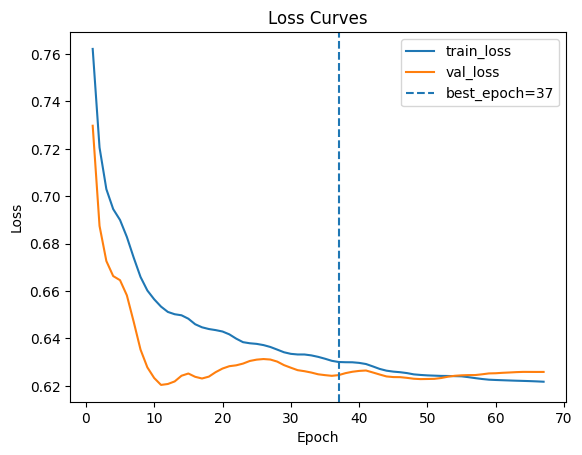

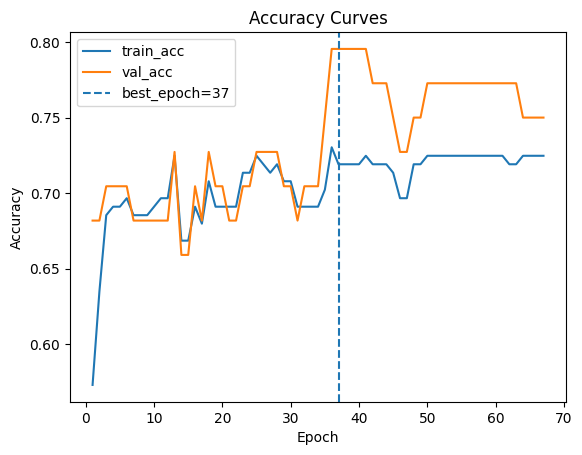

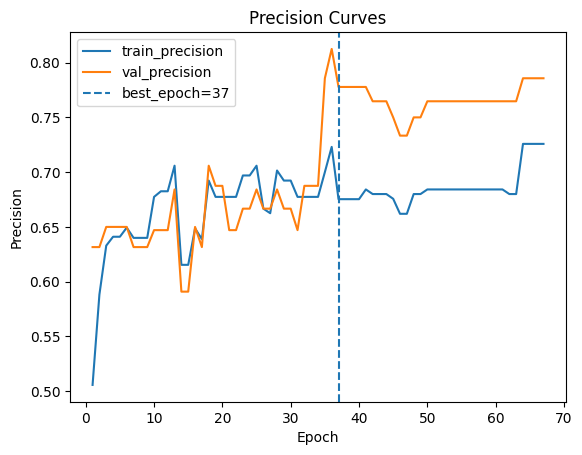

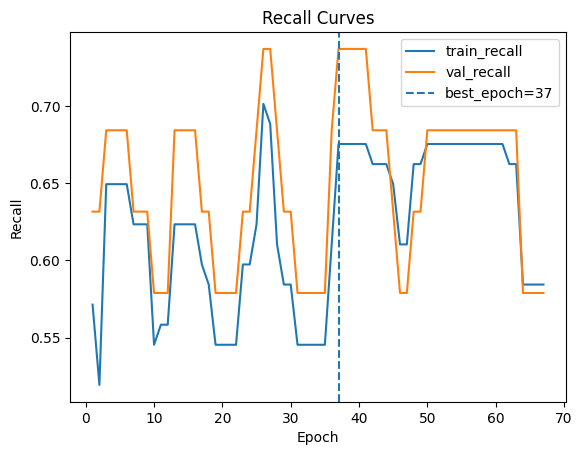

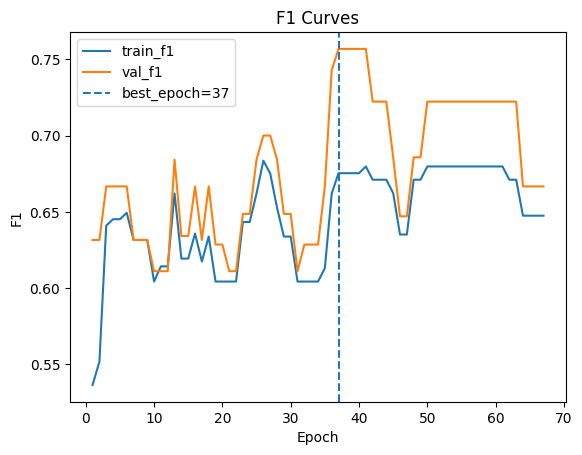

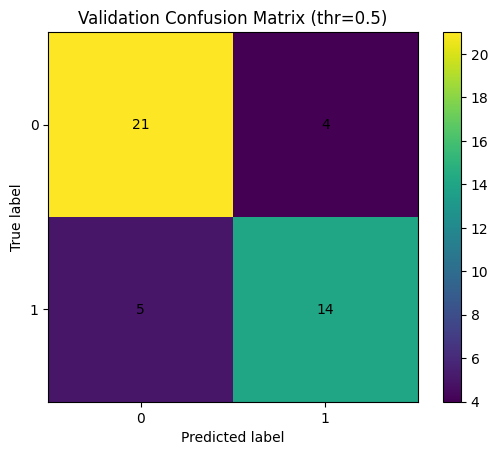

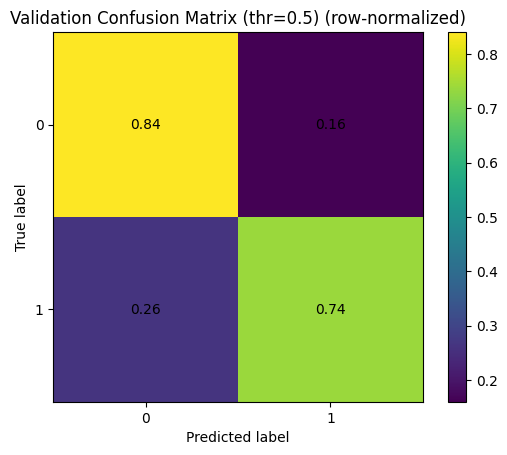

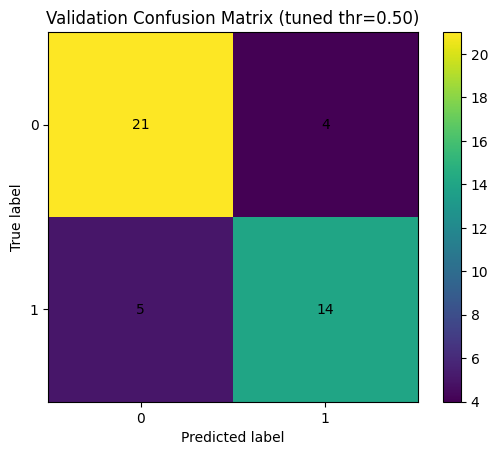

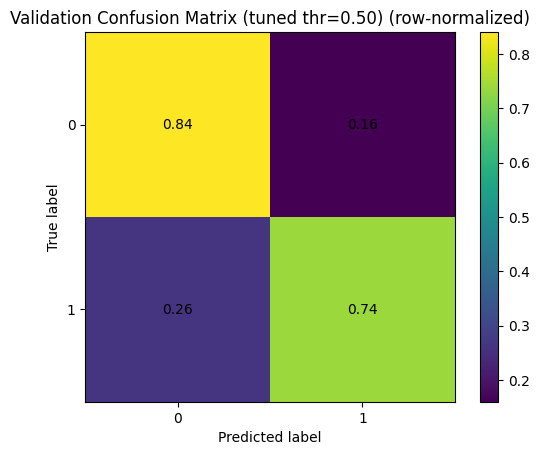

Saved figures to: outputs/figs


In [98]:
import os
import numpy as np
import matplotlib.pyplot as plt

def _ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)

def plot_metric_curve(history: dict, train_key: str, val_key: str,
                      title: str, ylabel: str,
                      best_epoch: int | None = None,
                      save_path: str | None = None) -> None:
    """
    Plot a single metric curve (train vs val). One figure per metric (report-friendly).
    """
    epochs = np.arange(1, len(history[train_key]) + 1)

    plt.figure()
    plt.plot(epochs, history[train_key], label=train_key)
    plt.plot(epochs, history[val_key], label=val_key)

    if best_epoch is not None and 1 <= best_epoch <= len(epochs):
        plt.axvline(best_epoch, linestyle="--", label=f"best_epoch={best_epoch}")

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

def plot_all_curves(history: dict, best_epoch: int | None = None, out_dir: str | None = None) -> None:
    """
    Plot all required curves for the homework:
      - Loss, Accuracy, Precision, Recall, F1
    """
    if out_dir is not None:
        _ensure_dir(out_dir)

    items = [
        ("train_loss", "val_loss", "Loss Curves", "Loss", "loss.png"),
        ("train_acc", "val_acc", "Accuracy Curves", "Accuracy", "acc.png"),
        ("train_precision", "val_precision", "Precision Curves", "Precision", "precision.png"),
        ("train_recall", "val_recall", "Recall Curves", "Recall", "recall.png"),
        ("train_f1", "val_f1", "F1 Curves", "F1", "f1.png"),
    ]

    for tr_key, va_key, title, ylabel, fname in items:
        save_path = os.path.join(out_dir, fname) if out_dir is not None else None
        plot_metric_curve(
            history=history,
            train_key=tr_key,
            val_key=va_key,
            title=title,
            ylabel=ylabel,
            best_epoch=best_epoch,
            save_path=save_path
        )

def confusion_matrix_from_counts(tp: int, fp: int, fn: int, tn: int) -> np.ndarray:
    """
    Standard 2x2 layout:
      [[TN, FP],
       [FN, TP]]
    """
    return np.array([[tn, fp],
                     [fn, tp]], dtype=int)

def plot_confusion_matrix(cm: np.ndarray, title: str,
                          normalize: str | None = None,
                          save_path: str | None = None) -> None:
    """
    normalize:
      - None: raw counts
      - "row": row-normalized (per true class)
    """
    cm_plot = cm.astype(float)

    if normalize == "row":
        row_sum = cm_plot.sum(axis=1, keepdims=True) + 1e-12
        cm_plot = cm_plot / row_sum
        title = f"{title} (row-normalized)"

    plt.figure()
    plt.imshow(cm_plot)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    # Annotate
    for i in range(2):
        for j in range(2):
            val = cm_plot[i, j]
            txt = f"{val:.2f}" if normalize else f"{int(cm[i, j])}"
            plt.text(j, i, txt, ha="center", va="center")

    plt.colorbar()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


# ---------------------------
# Run plots
# ---------------------------

# Optional: save all figures for your PDF report
FIG_DIR = "outputs/figs"

# 1) Curves (Loss/Acc/Prec/Rec/F1)
plot_all_curves(history, best_epoch=best_epoch, out_dir=FIG_DIR)

# 2) Confusion matrices at thr=0.5
logits = get_logits_final(
    model=model, X=X_d, edge_index=edge_index_d, cfg=cfg,
    edge_index_hat=edge_index_hat_d, norm_hat=norm_hat_d
)
val_m_05 = compute_metrics_from_logits(logits, y_d, val_idx_d, thr=0.5)
cm_05 = confusion_matrix_from_counts(val_m_05["tp"], val_m_05["fp"], val_m_05["fn"], val_m_05["tn"])

plot_confusion_matrix(cm_05, title="Validation Confusion Matrix (thr=0.5)",
                      normalize=None, save_path=os.path.join(FIG_DIR, "cm_val_thr0p5.png"))
plot_confusion_matrix(cm_05, title="Validation Confusion Matrix (thr=0.5)",
                      normalize="row", save_path=os.path.join(FIG_DIR, "cm_val_thr0p5_row.png"))

# 3) Confusion matrices at tuned threshold (optional)
best_thr, best_val_m = tune_threshold_on_val(logits, y_d, val_idx_d, steps=41)
cm_best = confusion_matrix_from_counts(best_val_m["tp"], best_val_m["fp"], best_val_m["fn"], best_val_m["tn"])

plot_confusion_matrix(cm_best, title=f"Validation Confusion Matrix (tuned thr={best_thr:.2f})",
                      normalize=None, save_path=os.path.join(FIG_DIR, "cm_val_tuned.png"))
plot_confusion_matrix(cm_best, title=f"Validation Confusion Matrix (tuned thr={best_thr:.2f})",
                      normalize="row", save_path=os.path.join(FIG_DIR, "cm_val_tuned_row.png"))

print("Saved figures to:", FIG_DIR)


Cell 16 — Export results (for report)

In [96]:
import os
import sys
import json
import time
import hashlib
from datetime import datetime
from typing import Any, Dict, Optional

import numpy as np
import torch

# -----------------------------
# Helpers: safe serialization
# -----------------------------
def _to_py(obj: Any):
    """Convert torch/numpy types to JSON-serializable Python types."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if torch.is_tensor(obj):
        if obj.numel() == 1:
            return float(obj.item())
        return obj.detach().cpu().tolist()
    return obj

def sanitize_for_json(x: Any):
    """Recursively sanitize dict/list structures into JSON-safe python objects."""
    if isinstance(x, dict):
        return {str(k): sanitize_for_json(_to_py(v)) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [sanitize_for_json(_to_py(v)) for v in x]
    return _to_py(x)

def atomic_json_dump(payload: Dict[str, Any], path: str, indent: int = 2) -> None:
    """Write JSON atomically to avoid partially-written files."""
    tmp_path = path + ".tmp"
    with open(tmp_path, "w") as f:
        json.dump(payload, f, indent=indent)
    os.replace(tmp_path, path)

def sha1_of_file(path: str) -> str:
    """Compute SHA1 checksum of a file (useful to cite KGML versions in report)."""
    h = hashlib.sha1()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

# -----------------------------
# Collect run metadata
# -----------------------------
save_dir = getattr(cfg, "save_dir", "outputs")
os.makedirs(save_dir, exist_ok=True)

timestamp_utc = datetime.utcnow().isoformat() + "Z"

env_payload = {
    "timestamp_utc": timestamp_utc,
    "python": sys.version.split()[0],
    "pytorch": torch.__version__,
    "cuda_available": bool(torch.cuda.is_available()),
    "device": str(device) if "device" in globals() else "unknown",
    "seed": int(getattr(cfg, "split_seed", getattr(cfg, "seed", 42))),
}

# Optional: include KGML file checksums (excellent for reproducibility)
kgml_payload = None
if "kgml_paths" in globals() and isinstance(kgml_paths, (list, tuple)) and len(kgml_paths) > 0:
    kgml_payload = []
    for p in kgml_paths:
        try:
            kgml_payload.append({
                "path": str(p),
                "sha1": sha1_of_file(p),
                "bytes": int(os.path.getsize(p)),
            })
        except Exception as e:
            kgml_payload.append({"path": str(p), "error": str(e)})

# -----------------------------
# Graph stats (required by homework)
# -----------------------------
graph_payload = None
if "genes" in globals() and "edge_index" in globals() and "y" in globals():
    N = len(genes)
    graph_payload = {
        "num_nodes": int(N),
        "num_edges_undirected": int(edge_index.size(1) // 2),
        "num_edges_directed": int(edge_index.size(1)),
        "class0": int((y == 0).sum().item()),
        "class1": int((y == 1).sum().item()),
        "zero_reaction_genes": int((rxn_counts == 0).sum()) if "rxn_counts" in globals() else None,
    }

    # Include parsing stats if available
    if "graph_stats" in globals() and isinstance(graph_stats, dict) and "parsing_stats" in graph_stats:
        graph_payload["per_pathway_parsing_stats"] = graph_stats["parsing_stats"]
else:
    graph_payload = {"error": "Graph objects not found in globals(). Run cells 3–6 first."}

# -----------------------------
# Split stats (required by homework)
# -----------------------------
split_payload = split_stats if "split_stats" in globals() else None

# -----------------------------
# Training history (for plots + report)
# -----------------------------
history_payload = history if "history" in globals() else None

# -----------------------------
# Metrics payload (required by homework)
# Must include loss + acc + precision + recall + f1 on train/val
# -----------------------------
metrics_payload = {}

# Prefer metrics produced in Cell 14/15 if present
if "train_metrics" in globals():
    metrics_payload["train_metrics_thr_0p5"] = train_metrics
if "val_metrics" in globals():
    metrics_payload["val_metrics_thr_0p5"] = val_metrics

# Optionally attach threshold tuning results (ONLY if you disclose in report)
if "best_thr" in globals() and "best_val_metrics" in globals():
    metrics_payload["val_threshold_tuning"] = {
        "best_thr_on_val": best_thr,
        "val_metrics_at_best_thr": best_val_metrics,
    }

# If losses were not included in train_metrics/val_metrics, you can compute & attach them here
# (This ensures the homework requirement "report loss" is satisfied.)
if "criterion" in globals() and "logits" in globals() and "train_idx_d" in globals() and "val_idx_d" in globals():
    try:
        with torch.no_grad():
            train_loss = float(criterion(logits[train_idx_d], y_d[train_idx_d]).item())
            val_loss = float(criterion(logits[val_idx_d], y_d[val_idx_d]).item())
        metrics_payload.setdefault("train_metrics_thr_0p5", {})["loss"] = train_loss
        metrics_payload.setdefault("val_metrics_thr_0p5", {})["loss"] = val_loss
    except Exception as e:
        metrics_payload["loss_compute_error"] = str(e)

# -----------------------------
# Training summary (early stopping, best checkpoint)
# -----------------------------
train_summary = None
if "best_epoch" in globals():
    train_summary = {"best_epoch": int(best_epoch)}
    if "best_val" in globals() and best_val is not None:
        train_summary["best_val_metrics_thr_0p5"] = best_val

# -----------------------------
# Save model checkpoint (recommended)
# -----------------------------
ckpt_path = None
if "model" in globals() and isinstance(model, torch.nn.Module):
    try:
        ckpt = {
            "timestamp_utc": timestamp_utc,
            "cfg": cfg.__dict__,
            "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
        }
        ckpt_path = os.path.join(save_dir, "model_state.pt")
        torch.save(ckpt, ckpt_path)
    except Exception as e:
        ckpt_path = f"checkpoint_save_error: {e}"

# -----------------------------
# Final results schema
# -----------------------------
results = {
    "cfg": cfg.__dict__,
    "environment": env_payload,
    "kgml_files": kgml_payload,          # optional but excellent
    "graph_stats": graph_payload,
    "split_stats": split_payload,
    "training_summary": train_summary,
    "history": history_payload,          # curves for reproducibility
    "metrics": metrics_payload,
    "artifacts": {
        "model_checkpoint": ckpt_path,
    }
}

# Sanitize for JSON + write
results = sanitize_for_json(results)

out_path = os.path.join(save_dir, "results.json")
atomic_json_dump(results, out_path, indent=2)

print("Saved:", out_path)
if ckpt_path is not None:
    print("Saved checkpoint:", ckpt_path)


Saved: outputs/results.json
Saved checkpoint: outputs/model_state.pt


/tmp/ipython-input-1474707681.py:58: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp_utc = datetime.utcnow().isoformat() + "Z"


Cell 17 — Graph diagnostics (connected components, isolated nodes, degree stats)

In [97]:
from collections import deque
from typing import Dict, Any, Tuple

import numpy as np
import torch

def graph_diagnostics(
    edge_index: torch.Tensor,
    num_nodes: int,
    assume_bidirectional: bool = True,  # your graph stores both directions; set False if unsure
) -> Dict[str, Any]:
    """
    Compute key diagnostics required/useful for the homework report.

    Metrics:
      - isolated nodes (degree == 0)
      - connected components (treat as UNDIRECTED)
      - largest component size and fraction of nodes it covers
      - degree summary (min/median/mean/max)
      - edge density (undirected) ~ 2E / (N(N-1)) [excluding self-loops]
      - self-loop count

    Notes:
      - If your edge_index already contains both directions, set assume_bidirectional=True.
      - If not, we will symmetrize adjacency for correct component counting.
    """
    if edge_index.ndim != 2 or edge_index.size(0) != 2:
        raise ValueError("edge_index must have shape [2, E].")

    # --- Degree computation (fast, torch) ---
    # Using src-degree is fine if edges include both directions; otherwise use both src+dst.
    src = edge_index[0]
    dst = edge_index[1]

    deg = torch.zeros(num_nodes, dtype=torch.long)
    deg.scatter_add_(0, src, torch.ones_like(src, dtype=torch.long))
    if not assume_bidirectional:
        deg.scatter_add_(0, dst, torch.ones_like(dst, dtype=torch.long))

    isolated = int((deg == 0).sum().item())

    # --- Self-loops (for reporting / debugging normalization) ---
    self_loops = int((src == dst).sum().item())

    # --- Build UNDIRECTED adjacency for connected components ---
    # Convert to CPU numpy once (avoid repeated device transfers)
    ei = edge_index.detach().cpu().numpy()
    u_arr = ei[0].astype(np.int64)
    v_arr = ei[1].astype(np.int64)

    # Adjacency list
    adj = [[] for _ in range(num_nodes)]
    if assume_bidirectional:
        # If edges are already stored both ways, we can add as-is (still OK if duplicates exist)
        for u, v in zip(u_arr, v_arr):
            if u == v:
                continue
            adj[u].append(v)
    else:
        # Symmetrize on the fly to guarantee UNDIRECTED connectivity is correct
        for u, v in zip(u_arr, v_arr):
            if u == v:
                continue
            adj[u].append(v)
            adj[v].append(u)

    # --- Connected components (BFS) ---
    visited = np.zeros(num_nodes, dtype=bool)
    comp_sizes = []

    for start in range(num_nodes):
        if visited[start]:
            continue

        q = deque([start])
        visited[start] = True
        size = 0

        while q:
            node = q.popleft()
            size += 1
            for nbr in adj[node]:
                if not visited[nbr]:
                    visited[nbr] = True
                    q.append(nbr)

        comp_sizes.append(size)

    num_components = int(len(comp_sizes))
    largest_comp = int(max(comp_sizes)) if comp_sizes else 0
    largest_frac = float(largest_comp / max(num_nodes, 1))

    # --- Degree summary ---
    deg_np = deg.cpu().numpy()
    deg_min = int(deg_np.min()) if num_nodes > 0 else 0
    deg_max = int(deg_np.max()) if num_nodes > 0 else 0
    deg_mean = float(deg_np.mean()) if num_nodes > 0 else 0.0
    deg_median = float(np.median(deg_np)) if num_nodes > 0 else 0.0

    # --- Edge density (undirected, excluding self-loops) ---
    # Count undirected edges approximately:
    # - If assume_bidirectional=True and you stored both directions, undirected_edges ~= (E - self_loops)/2
    # - Else undirected_edges ~= E - self_loops
    E = int(edge_index.size(1))
    if assume_bidirectional:
        undirected_edges = int((E - self_loops) // 2)
    else:
        undirected_edges = int(E - self_loops)

    # Density for simple undirected graph without self-loops: 2m / (N(N-1))
    denom = num_nodes * (num_nodes - 1)
    density = float((2 * undirected_edges) / denom) if denom > 0 else 0.0

    return {
        "num_nodes": int(num_nodes),
        "num_edges_directed": int(E),
        "self_loops_directed": int(self_loops),
        "num_edges_undirected_est": int(undirected_edges),
        "edge_density_undirected": density,
        "isolated_nodes": int(isolated),
        "num_components_undirected": int(num_components),
        "largest_component_size": int(largest_comp),
        "largest_component_fraction": largest_frac,
        "deg_min": deg_min,
        "deg_median": deg_median,
        "deg_mean": deg_mean,
        "deg_max": deg_max,
        "assume_bidirectional": bool(assume_bidirectional),
    }

# Run diagnostics (your construction stores both directions -> assume_bidirectional=True)
diag = graph_diagnostics(edge_index, num_nodes=len(genes), assume_bidirectional=True)

print("=== Graph Diagnostics ===")
for k, v in diag.items():
    print(f"{k:28s}: {v}")


=== Graph Diagnostics ===
num_nodes                   : 222
num_edges_directed          : 1180
self_loops_directed         : 0
num_edges_undirected_est    : 590
edge_density_undirected     : 0.024051200521788756
isolated_nodes              : 98
num_components_undirected   : 99
largest_component_size      : 124
largest_component_fraction  : 0.5585585585585585
deg_min                     : 0
deg_median                  : 4.0
deg_mean                    : 5.315315315315315
deg_max                     : 19
assume_bidirectional        : True
